Before you turn this problem in, make sure everything runs as expected. First, **restart the kernel** (in the menubar, select Kernel $\rightarrow$ Restart) and then **run all cells** (in the menubar, select Cell $\rightarrow$ Run All).

Make sure you fill in any place that says `YOUR CODE HERE` or "YOUR ANSWER HERE", as well as your name and collaborators below: 


In [1]:
NAME = ""
STUDENT_NUMBER = ""

### Important: When handing in your homework:
- Hand in the notebook named as follows: Studentname_snumber.ipynb
- If you find any mistakes/have suggestions/like to complain about the material, please e-mail Emma at `emma.gerritse@ru.nl`
- Do not remove any cells in the notebook, as it might break the auto-grader
- When using platforms other than Jupyter Labs to make your assignments, it might add additional metadata to the Jupyter Notebook file, which will break the autograder. To prevent this, please copy the answers back into the original notebook.
- It is okay to use VS Code or PyCharm. If you want to be sure if your favorite editor is allowed, please ask your TA for help, or check manually. Google Colab is known to add extra metadata, so please do not use this, or copy back the cells to an empty file.  
- Only type your answers in places where asked.
- Before handing in your Notebook, make sure to run `Kernel > Restart Kernel and Run All Cells` one more time, and make sure it runs to the last cell without raising any errors. 

To make sure your answers work correctly, please make sure to use the variable names as given in the assignment. This will look like:

```
    some_variablename = None

    # YOUR CODE HERE
    raise NotImplementedError()
```
You have to remove the `raise NotImplementedError()` and answer the assignment as follows:

```
    some_variablename = None
    # YOUR CODE HERE
    your_code
    more_code
    some_variable = some_results
```

Not using the specified variable names may result in reduced points.

---

# Assignment 3: Naive Bayes and Trees

### Deadline: October 24th 

In this assignment, we will be implementing two different algorithms and delving a little bit more into programming.

We will first explore Naive Bayes using a simple dataset and a real dataset.

Note: this example is completely made up in a way such that your answer is easy to inspect.

In [2]:
import numpy as np

spam_dataset = [
    ["free", "money"],
    ["dear", "friend"],
    ["friend", "free"],
    ["dear", "friend"],
    ["free", "money"],
]

dictionary = {"dear": 0, "friend": 1, "free": 2, "money": 3}
y = np.array([True, False, False, False, True])

### Exercise 1.1.1

Using the `dictionary`, create the vector encoding of the spam dataset and save it as a numpy array `X`.

For each data point, we create an array with a length equal to the number of key-value pairs in the dictionary.
The array's contents will be $0$ for each word that is not present in the message, and $1$ for each word that is present in the message.

For example, the message `['dear', 'friend']` should be encoded as `[1, 1, 0, 0]`, and we will end up with a matrix of shape `(5,4)` filled with ones and zeros. 

In [3]:
np.vectorize()
def occurence_count(text: list[str], word: str) -> int:
    return sum(word == w for w in text)

X = np.zeros((len(spam_dataset), len(dictionary)))
i, j = np.indices(X.shape)

def f(entry: list[str]): 
    return [occurence_count(entry, w) for w in dictionary]
    
X = np.apply_along_axis(f, 1, spam_dataset)

X

array([[0, 0, 1, 1],
       [1, 1, 0, 0],
       [0, 1, 1, 0],
       [1, 1, 0, 0],
       [0, 0, 1, 1]])

In [4]:
"""Checks whether previous output is correct"""

"""DO NOT MODIFY THIS CELL"""


'DO NOT MODIFY THIS CELL'

### Exercise 1.1.2


We now implement a function `predict`, with for a np Array `X`, which is the bag-of-words representation of a number of sentences, as seen above.  
`X` could be an evaluation or test set. 
Our goal is to predict the most likely class (either 0 or 1) for each data point.
For that, compute the following things:
1. For each class $C_i$, compute the probability of each word $x_j \in \vec{x}$, where $\vec{x}$ is a new sentence, belongs to that class using $$ p(C_i) \prod p(x_j | C_i) $$

To make this toy example easier to understand, we will save an example for
 $p(C_i)$  in the parameter `class_probabilities`,  and an example for $p(x_j | C_i) $ is stored in `word_weights_false` and `word_weights_true`.


2. You should now have two numpy arrays of shape $(N,)$, one that predicts the probability of $\vec{x}$ being `False`, and one that predicts the probability of $\vec{x}$ being `True`. Combine these into a single numpy array of shape $(N,2)$, for example using Numpy stack.
   
3. Return a numpy array `predicted_class` of shape $(N,)$, with $N$ the number of samples in the input. The elements in this array should be $0$ if the sample is most likely `False`, and $1$ if the sample is most likely `True`. One possible method is using numpy argmax.


In [5]:
class_probabilities = [0.35, 0.65]  # [p(C_0), P(C_1)]
word_weights_false = np.array(
    [0.25, 0.125, 0.125, 0.5]
)  # p(dear|False), p(friend|False), p(free|False), p(money|False)
word_weights_true = np.array(
    [0.7, 0.1, 0.1, 0.1]
)  # p(dear|True), p(friend|True), p(free|True), p(money|True)
X_dummy = np.array(
    [[1, 0, 0, 1], [1, 0, 1, 1]]  # message: dear money
)  # message: dear free money


def predict(X):
    predicted_probs = np.stack([c_prob * np.prod(w_weights ** X, axis=1) 
                                for c_prob, w_weights in zip(class_probabilities, [word_weights_false, word_weights_true])], 
                               axis=1)
    
    print(predicted_probs)
    predicted_class = np.argmax(predicted_probs, axis=1)
    return predicted_class

print(predict(X_dummy))

[[0.04375    0.0455    ]
 [0.00546875 0.00455   ]]
[1 0]


In [6]:
"""Checks whether previous output is correct"""

"""DO NOT MODIFY THIS CELL"""


'DO NOT MODIFY THIS CELL'

### Exercise 1.1.3

__Note: in case you get stuck here, continue with Exercise 1.2.1.__
### Explanation about OOP in Python and SK Learn:

Previously, we implemented our models using a function that computes the weights, and another separate function that computes the prediction. However, having to manually pass these weights around is not a very nice way of coding. That is why, in practice, most machine learning libraries are implemented in an object-oriented manner. 

When using the scikit modules in the previous exercises, you might have noticed that all of these modules create a class instance of a model. 

For example, in the logistic regression module you used last week, you would make an instance of the class using

```
clf = LogisticRegression(random_state=0).fit(X, y)
```

`clf` is now an instance of the class `LogisticRegression` and the weights are stored in there as member variables. 
When we call the `predict` method, we don't have to pass in the weights as a parameter ourselves, since they are stored in the instance of the class. 


### Exercise:

We will create our own class for the Naive Bayes predictor.

We already made the method `class_weights`, with parameters `X`, `y`, and `label`. Note that `class` here means the classification class (So belonging to class $C_0$, or having `label = 0`, means not being spam. And belonging to class $C_1$, or having or having `label = 1`, means it's spam) and not the Object Oriented Programming class.

Next we made the Laplace smoothing function as used in `class_weights`, to prevent 0 probabilities showing up. The smoothing rate can be changed when initializing an instance of `NaiveBayesPredictor`, but it set on a very small number as default. 

We also made the `fit` function, which will fit Naive Bayes on a given dataset `X` and `y`. It will compute the `class_probabilites` $p(C_i)$, which is the prior probability of a sample belonging to a class (so $p(c_1)=p(spam) = \frac{2}{5}$) and the `word_weights` $p(x_j|C_i)$ (so the probability of $x_0=$ dear being in a message with label `0` or `not_spam` is $p(x_0|C_0) = \frac{2}{6}$).

More specifically, in our example `X` as given in the first cell of this assignment, there are 3 samples in the class `y == 0` (i.e., non-spam), `words_per_class` is `[2, 3, 1, 0.]`. 

The probabilities of a sample containing one of these words while not being spam are $p(dear|C_0) = \frac{2}{6}$, $p(friend|C_0)=\frac{3}{6}$, $p(free|C_0)=\frac{1}{6}$ and $p(money|C_0)=\frac{0}{6}$ respectively. 

There are 2 samples in the class `y == 1` (i.e., spam), `words_per_class` is `[0. 0. 2. 2.]`. The probabilities of a sample containing one of these words while being spam are $p(dear|C_1) = \frac{0}{4}$, $p(friend|C_1)=\frac{0}{4}$, $p(free|C_1)=\frac{2}{4}$ and $p(money|C_1)=\frac{2}{4}$ respectively.

Before implementing the Predict Method, you can already run the cell below and answer __exercise 1.1.4__. When you feel comfortable with what `class_probabilities` and `word_weights` represent, move on to the part below: 


#### Predict method

We now implement the method `predict`, with parameters `self` and `X`.

Reuse your code from the previous exercise, but now add it as a method to the class. Note that now, you should be using the parameters `self.class_probabilities`, `self.word_weights_false` and `self.word_weights_true`.

In [7]:
class NaiveBayesPredictor:
    def __init__(self, smooth=0.000001):
        self.smooth = smooth
        self.word_weights_true = None  # This will be a numpy array with shape (N,1)
        self.word_weights_false = None  # This will be a numpy array with shape (N,1)
        self.class_probabilities = None  # This will be a numpy array with shape (1,2)

    def laplace_smoothing(self, words_per_class):
        # Compute the total number of words d in our dictionary
        len_words_per_class = len(words_per_class)
        # Smooth the sum by add d*smooth
        smoothed_sum = np.sum(words_per_class) + len_words_per_class * self.smooth
        # Smooth the values by adding smooth
        smoothed_words_per_class = words_per_class + self.smooth
        # Compute the new probabilities
        smoothed_probabilities = smoothed_words_per_class * (1 / smoothed_sum)
        return smoothed_probabilities

    def class_weights(self, X, y, label):
        #  Compute the number of times a word appears per class
        words_per_class = np.sum(X[y == label], axis=0)
        # Compute the total number of samples in this category
        total_samples_in_class = np.sum(y == label)
        # Smooth the word counts to a probability
        smoothed_probabilities = self.laplace_smoothing(words_per_class)
        return smoothed_probabilities, total_samples_in_class

    def fit(self, X, y):
        # Compute the word weights for False
        self.word_weights_false, total_words_false = self.class_weights(X, y, 0)
        # Compute the word weights for True
        self.word_weights_true, total_words_true = self.class_weights(X, y, 1)
        # Compute the class priors
        word_counts = np.array([total_words_false, total_words_true])
        self.class_probabilities = np.array(word_counts / np.sum(word_counts)).T

    def predict(self, X):
        predicted_probs = np.stack([c_prob * np.prod(w_weights ** X, axis=1) 
                                    for c_prob, w_weights in zip(self.class_probabilities, 
                                                                 [self.word_weights_false, self.word_weights_true])], 
                                   axis=1)
        
        predicted_class = np.argmax(predicted_probs, axis=1)
        return predicted_class

### Exercise 1.1.4

Make an instance of the class NaiveBayesPredictor called `nbp`. Fit your predictor on the `X` and `y` we constructed above, and inspect the `class_probabilites`, `word_weights_false` and `word_weights_true`. 

In [8]:
nbp = NaiveBayesPredictor()
nbp.fit(X, y)
class_probabilities = class_probabilities
word_weights_false = word_weights_false
word_weights_true = word_weights_true


print(class_probabilities, word_weights_false, word_weights_true)

[0.35, 0.65] [0.25  0.125 0.125 0.5  ] [0.7 0.1 0.1 0.1]


In [9]:
"""Checks whether previous output is correct"""

"""DO NOT MODIFY THIS CELL"""


'DO NOT MODIFY THIS CELL'

### Exercise 1.1.5
Suppose we get these new messages:

```
 [['dear', 'friend'],
  ['free', 'money'],
  ['dear', 'friend', 'free', 'money'],
  ['money'],
  ['free', 'money'],
  ['friend', 'money']]
```

Use your found weights to predict the results

In [10]:
X_test = np.array(
    [[1, 1, 0, 0], [1, 0, 0, 1], [1, 1, 1, 1], [0, 0, 0, 1], [0, 0, 1, 1], [0, 1, 0, 1]]
)

y_pred = nbp.predict(X_test)

print(y_pred)

[0 1 0 1 1 0]


In [11]:
"""Checks whether previous output is correct"""

"""DO NOT MODIFY THIS CELL"""


'DO NOT MODIFY THIS CELL'

### Exercise 1.2.1

In this exercise, we will try using Multinomial Naive Bayes on an edited version of a real dataset, check out the real dataset on kaggle [here](https://www.kaggle.com/datasets/elvinrustam/books-dataset). 

We have provided the following two extra rows for you: 
1. Cleaned_Description: Here, we have performed some common Natural Language Processing methods to make the data better for processing (You will learn more about this in your NLP course)
2. A column `Fiction`, where we have the label we are going to predict. 

In [12]:
import pandas as pd

books = pd.read_csv("mini_book_dataset.csv")
books

,Title,Authors,Description,Cleaned_Description,Fiction
0,Journey Through Heartsongs,"By Stepanek, Mattie J. T.",Collects poems written by the eleven-year-old ...,collect poem written elevenyearold muscular dy...,False
1,In Search of Melancholy Baby,"By Aksyonov, Vassily, Heim, Michael Henry, and...",The Russian author offers an affectionate chro...,the russian author offer affectionate chronicl...,False
2,Germs : Biological Weapons and America's Secre...,"By Miller, Judith, Engelberg, Stephen, and Bro...","Deadly germs sprayed in shopping malls, bomb-l...",deadly germ sprayed shopping mall bomblet spew...,False
3,The Good Book: Reading the Bible with Mind and...,"By Gomes, Peter J.","""The Bible and the social and moral consequenc...",the bible social moral consequence derive inte...,False
4,Hill Rat: Blowing the Lid Off Congress,"By Jackley, John L.",As a top aide to powerful Texas Congressman Ro...,a top aide powerful texas congressman ronald c...,False
...,...,...,...,...,...
3995,Vinegars,"By Gordon-Smith, Clare",Explains how to use the growing assortment of ...,explains use growing assortment vinegar enhanc...,False
3996,The Herbal Grove: A Celebration of the Beauty ...,"By Forsell, Mary and Cenicola, Tony (PHT)",The Herbal Grove is a lavishly illustrated wor...,the herbal grove lavishly illustrated work fun...,False
3997,"Relax, This Won't Hurt: Painless Answers to Wo...","By Reichman, Judith, M.D.","From a doctor millions of women already trust,...",from doctor million woman already trust relax ...,False
3998,Open: Inside the Ropes at Bethpage Black,"By Feinstein, John","With Open, John Feinstein goes behind the scen...",with open john feinstein go behind scene tell ...,False


## Exercise 1.2.1

As we explained, we did some pre-processing on the data for you, to make your life easier.
Take a look at the first three elements of Description and Cleaned Description. 
What type of preprocessing do you think occurred?
Compare the normal and clean versions, and try to describe at least three things we did during pre-processing. In total, four different pre-processing methods were used. 

In [13]:
books[["Description", "Cleaned_Description"]]

,Description,Cleaned_Description
0,Collects poems written by the eleven-year-old ...,collect poem written elevenyearold muscular dy...
1,The Russian author offers an affectionate chro...,the russian author offer affectionate chronicl...
2,"Deadly germs sprayed in shopping malls, bomb-l...",deadly germ sprayed shopping mall bomblet spew...
3,"""The Bible and the social and moral consequenc...",the bible social moral consequence derive inte...
4,As a top aide to powerful Texas Congressman Ro...,a top aide powerful texas congressman ronald c...
...,...,...
3995,Explains how to use the growing assortment of ...,explains use growing assortment vinegar enhanc...
3996,The Herbal Grove is a lavishly illustrated wor...,the herbal grove lavishly illustrated work fun...
3997,"From a doctor millions of women already trust,...",from doctor million woman already trust relax ...
3998,"With Open, John Feinstein goes behind the scen...",with open john feinstein go behind scene tell ...


1. Moved to all lowercase;
2. Removed any quotation marks around description (entry 3);
3. Removed punctuation (entry 3998). 

# Exercise 1.2.2

As always, we first need to do a train test split.
Make a numpy array called books_X, which stores all entries in the `Cleaned_Description` column, and the array `y`, which stores the `Fiction` column. Make sure that `book_X_train` and `y_train` both have shape `(3000,)`

Then, make a train-test split with a test size of 0.25 and a random state of 42.

In [14]:
import numpy as np
from sklearn.model_selection import train_test_split

books_X = books["Cleaned_Description"]
y = books["Fiction"]

test_size = 0.25
random_state = 42
books_X_train, books_X_test, y_train, y_test = train_test_split(books_X, y, test_size=test_size, random_state=random_state)


books_X_train.shape, y_train.shape

((3000,), (3000,))

In [15]:
"""Checks whether previous output is correct"""

"""DO NOT MODIFY THIS CELL"""


'DO NOT MODIFY THIS CELL'

# Exercise 1.2.3

Instead of having to do the vectorization manually, we will use the sklearn [CountVectorizer](https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.CountVectorizer.html). This one has some handy features like only using the most common 2000 words. 
If we don't do this, we might end up with vectors over 100 000 long, which will probably give out of memory errors on most standard laptops. 

Remember, to prevent premature featurization and thus data leakage, to fit this vectorizer on `books_X_train` and then transform it onto `books_X_test`, using `max_features` of 2000.

In [16]:
from sklearn.feature_extraction.text import CountVectorizer

max_features = 2000
vectorizer = CountVectorizer(max_features=max_features)
vectorizer.fit(books_X_train, y_train)
unique_words = vectorizer.get_feature_names_out()
print(unique_words)
vectorizer.transform(books_X_test)

['10' '100' '100000' ... 'youre' 'youth' 'youve']


<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 35231 stored elements and shape (1000, 2000)>

In [17]:
"""Checks whether previous output is correct"""

"""DO NOT MODIFY THIS CELL"""


'DO NOT MODIFY THIS CELL'

## Exercise 1.2.3

Using the [Multinomial Naive Bayes](https://scikit-learn.org/stable/modules/generated/sklearn.naive_bayes.MultinomialNB.html) in SKlearn, fit Naive Bayes on the train set, and predict the test set as `y_pred`. 

In [18]:
from sklearn.naive_bayes import MultinomialNB

mnb = MultinomialNB()
mnb.fit(vectorizer.transform(books_X_train), y_train)

y_pred = mnb.predict(vectorizer.transform(books_X_test))

In [19]:
"""Checks whether previous output is correct"""

"""DO NOT MODIFY THIS CELL"""


'DO NOT MODIFY THIS CELL'

## Exercise 1.2.4

Using sklearn `confusion_matrix`, compute the confusion matrix. 

In [20]:
from sklearn.metrics import confusion_matrix

cfm = confusion_matrix(y_test, y_pred).flatten()
cfm


array([639,  61,  32, 268])

In [21]:
"""Checks whether previous output is correct"""

"""DO NOT MODIFY THIS CELL"""


'DO NOT MODIFY THIS CELL'

In [22]:
[(x[0],x[1], c) for c, x in zip(cfm, [(x, y) for x in ("Positive", "Negative") for y in ("Positive", "Negative")])]

[('Positive', 'Positive', np.int64(639)),
 ('Positive', 'Negative', np.int64(61)),
 ('Negative', 'Positive', np.int64(32)),
 ('Negative', 'Negative', np.int64(268))]

Use the following cell to inspect your confusion matrix:

<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W
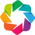

:Overlay
   .HeatMap.I :HeatMap   [x,y]   (z)
   .Labels.I  :Labels   [x,y]   (z)

In [23]:
import holoviews as hv
from holoviews import opts
from holoviews.operation import gridmatrix

hv.extension('bokeh')
hv.renderer("bokeh").webgl = False
img_stack = hv.HeatMap([(x[0],x[1], c) for c, x in zip(cfm, [(x, y) for x in ("Positive", "Negative") for y in ("Positive", "Negative")])]).opts(    cmap="Plasma", tools=['hover'])
img_stack * hv.Labels(img_stack).opts(width = 500, xlabel="Predicted", ylabel="Actual")

### Exercise 1.2.5: __(Extra: not graded)__

Are you interested in which words would be the best predictors for `Fiction` and `Non Fiction`? In the class we made back in 1.1, we explicitly saved the word weights. 

Unfortunately, the official package does not do that. 
If we still want to get some idea of which features have the most influence in classifying an input as `Fiction` and `Non Fiction`, we can try making a prediction for the unity matrix $I$. (So this would represent a dataset of 2000 sentences, the first one just contains the first word, the second just the second, etc.). 

Try making a prediction for $I$ using [predict_proba](https://scikit-learn.org/stable/modules/generated/sklearn.naive_bayes.MultinomialNB.html), and using `unique_words` which we made before, try doing some exploration in which words have most influence on predicting either category. Something like [argsort](https://numpy.org/doc/stable/reference/generated/numpy.argsort.html) might help, but there are multiple options. 

If you want to spend even more time on this, try seeing for some false positives and false negatives as predicted above, if you can find examples where you can explain why it was predicted in the wrong class. 


In [24]:
#I = np.identity(max_features)

#probs = mnb.predict_proba(I)[:, 1]

# Lecture 6:

The part after this week is for Lecture 6. You can work ahead, but your TA might not be able to answer your questions yet.

### Exercise 2

Back to the penguin dataset again, but this time, we will look at decision trees. 
Instead of implementing the entire decision tree ourselves, we will only look at the impurity measures. For this, we will use our trusty Penguin dataset again.
Since we will only take a look at the effect of the Gini and Entropy impurity, we will not make a train/test split and also just remove the missing values. 


In [55]:
penguins = pd.read_csv("penguin.csv")

penguins_processed = penguins.dropna().copy()
penguins_processed["Adelie"] = penguins_processed["species"] == "Adelie"
y = penguins_processed["Adelie"].to_numpy().astype(int)
X = penguins_processed["flipper_length_mm"].to_numpy()
# For plotting
penguins_processed['Adelie'] = penguins_processed['Adelie'].map({True: 'Adelie', False: 'Other'})

(333,) (333,)


### Exercise 2.1.1

(Again, in case you get stuck here, continue with 2.2)

Take a look at the violin plot below. In a violin plot we can see the box plot, the density function and the datapoints scattered (with a bit of randomness). Read more about violin plots [here](https://en.wikipedia.org/wiki/Violin_plot).

If you were to decide on a threshold that can split the dataset with the least amount of impurity, what would you think it would be?


In [26]:
# Switching to Plotly, because the Bokeh violin plots don't look nice. 
hv.extension('plotly')

violin = hv.Violin(penguins_processed, kdims = 'Adelie', vdims='flipper_length_mm')

violin

<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W

:Violin   [Adelie]   (flipper_length_mm)

In [27]:
# Make an estimate here for a threshold
estimated_best_threshold = 197

In [28]:
"""Checks whether previous output is correct"""

"""DO NOT MODIFY THIS CELL"""


'DO NOT MODIFY THIS CELL'

### Exercise 2.1.2

Suppose we split our dataset $X$ into two splits, $D_1$ and $D_2$, of which $D_1 \cup D2 = X, D_1 \cap D2 = \emptyset$. 
The GINI for one leaf will then be

$$ GINI(D_i) = 1 - p(true|D_i)^2 - p(false|D_i)^2$$

The GINI for the entire split will be, for $D = \{D_1, D_2\}$:

$$ GINI(D) = \sum_{D_i \in D} \frac{|D_i|}{|D|}\cdot GINI(D_i)$$

Since the GINI and the Entropy score later are fairly similar, we will reuse the same `score_split` function to score a certain split. We only change the function for scoring the individual leaves.

Implement the `gini_one_split` function, which computes the $GINI(D)$ for one leaf.


In [29]:
def gini_one_split(y):
    p_true = sum(y) / len(y)
    p_false = 1 - p_true
    return 1 - p_true ** 2 - p_false**2

In [30]:
def score_split(X, y, threshold, split):
    y_above_thresh = y[X > threshold]
    y_below_thresh = y[X <= threshold]
    below = split(y_below_thresh)
    above = split(y_above_thresh)
    p_above_thresh = len(y_above_thresh) / len(y)
    p_below_thresh = len(y_below_thresh) / len(y)
    total = p_above_thresh * above + p_below_thresh * below
    return total


def gini(X, y, threshold):
    return score_split(X, y, threshold, gini_one_split)

In [31]:
### Test your gini, your estimated best should be the lowest

print(gini(X, y, estimated_best_threshold))
print(gini(X, y, estimated_best_threshold + 10))
print(gini(X, y, estimated_best_threshold - 10))

0.28168324269688794
0.28363136655819576
0.42150455662991826


In [32]:
"""Checks whether previous output is correct"""

"""DO NOT MODIFY THIS CELL"""


'DO NOT MODIFY THIS CELL'

### Exercise 2.1.3

We want to be able to inspect every single possible point where we can split our data. For that, we will create a numpy array `X_point_means` as follows:
1. Make an array of all values in `X` sorted in ascending order (Make sure to copy it, and not to change X), call it `X_sorted`
2. Compute, for each consecutive two elements in `X_sorted`, the mean. So
3. 
   ${X\_points\_mean} = [\frac{x_0+x_1}{2},\frac{x_1+x_2}{2}, \dots ]$ for $x_i \in {X\_sorted}$



In [33]:
X_sorted = np.sort(X)
X_point_means = [(X_sorted[i] + X_sorted[i+1])/2 for i in range(len(X)-1)]
print(X_sorted[0:5], X_point_means[0:5])

[172. 174. 176. 178. 178.] [np.float64(173.0), np.float64(175.0), np.float64(177.0), np.float64(178.0), np.float64(178.0)]


In [34]:
"""Checks whether previous output is correct"""

"""DO NOT MODIFY THIS CELL"""


'DO NOT MODIFY THIS CELL'

<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W
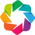

:Scatter   [x]   (y)

In [35]:
### Computing the GINI impurities for all splits in X_point_means and inspecting the best split:
hv.extension('bokeh')
hv.renderer("bokeh").webgl = False

gini_impurities = [gini(X, y, thresh) for thresh in X_point_means]


scatter_gini = hv.Scatter((X_point_means, gini_impurities), label = 'Gini').opts(width=800,height=800,tools = ['hover'])
scatter_gini

### Exercise 2.1.4


Suppose we split our dataset $X$ into two splits, $D_1$ and $D_2$, of which $D_1 \cup D_2 = X, D_1 \cap D_2 = \emptyset$. 
The entropy for one leaf will then be

$$Entropy(D_i) =  -p(true|D_i)log_2(p(true|D_i)) - p(false|D_i)log_2(p(false|D_i))$$


The Entropy for the entire split will be:

$$ Entropy = \sum_{D_i \in {D}} \frac{|D_i|}{|D|} \cdot Entropy(D_i)$$

As you see, the formula for computing the Entropy on both sets, is the same as computing the Gini on both sets. So we can reuse this `score_split` function. (Note that, since Python adopts some of the functional programming philosophy, you can pass functions as arguments.)

Implement the `Entropy` function given one split, and then use the `score_split` function to compute the total entropy on both splits. Don't forget to use smoothing, to prevent taking a logarithm of 0.

In [36]:

def entropy_one_split(y, smooth=0.00001):
    p_true = sum(y) / len(y)
    p_false = 1 - p_true
    
    return -p_true * np.log2(p_true) - p_false * np.log2(p_false)

In [37]:
def entropy(X, y, threshold):
    return score_split(X, y, threshold, entropy_one_split)

In [38]:
### Test your entropy, your estimated best should be the lowest

print(entropy(X, y, estimated_best_threshold))
print(entropy(X, y, estimated_best_threshold + 10))
print(entropy(X, y, estimated_best_threshold - 10))

0.648676115474681
0.6106281653784849
0.8803286242218554


In [39]:
"""Checks whether previous output is correct"""

"""DO NOT MODIFY THIS CELL"""


'DO NOT MODIFY THIS CELL'

In [40]:
entropies = [entropy(X, y, thresh) for thresh in X_point_means]

/tmp/nix-shell.Y6mnNy/ipykernel_561968/3431087418.py:5: RuntimeWarning: divide by zero encountered in log2
  return -p_true * np.log2(p_true) - p_false * np.log2(p_false)
/tmp/nix-shell.Y6mnNy/ipykernel_561968/3431087418.py:5: RuntimeWarning: invalid value encountered in scalar multiply
  return -p_true * np.log2(p_true) - p_false * np.log2(p_false)


In [41]:
# Inspect the plot below:

scatter_entropies = hv.Scatter((X_point_means, entropies), label = 'Gini').opts(width=800,height=800,tools = ['hover'])
scatter_gini * scatter_entropies


:Overlay
   .Scatter.Gini.I  :Scatter   [x]   (y)
   .Scatter.Gini.II :Scatter   [x]   (y)

Given the plot above, would the best guessed value for the split change?

## Exercise 2.2
### Using the package 

Again, like previous times, we will also see how the common package in numpy works. Last time, we tried predicting only one type of penguin.
Now we will do multi class prediction, so we will predict for each type of penguin. 
For that, we need to encode our Y vector with a one_hot encoding. Using OneHotEncoder in sklearn, make an onehot encoding of Y, and call the instance of the encoder class `enc`. Then, make a train/test split with the given test_size and random_state.

In [71]:
from sklearn.preprocessing import OneHotEncoder

test_size = 0.25
random_state = 42

islands = ["Torgersen", "Biscoe", "Dream"]  # Manual One Hot encoding for the columns
for island in islands:
    penguins_processed[island] = penguins_processed["island"] == island
feature_names = [
    "flipper_length_mm",
    "bill_depth_mm",
    "body_mass_g",
    "bill_depth_mm",
] + islands

X = penguins_processed[feature_names].to_numpy()
enc = OneHotEncoder(sparse_output=False)
y_onehot = enc.fit_transform(penguins_processed["species"].to_numpy().reshape(-1, 1))

class_names = enc.categories_[0]

X_train, X_test, y_train, y_test = train_test_split(X, y_onehot, test_size=test_size, random_state=random_state)

In [72]:
"""Checks whether previous output is correct"""

"""DO NOT MODIFY THIS CELL"""


'DO NOT MODIFY THIS CELL'

### Exercise 2.2.1

Train a decision tree on our given train data using the [DecisionTreeClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html)

Play around with the parameters criterion (which is splitting using either gini or max_depth), max_depth.

Which of these parameters works the best? Does a deeper tree depth mean that the model works better on the test set?

Try changing the parameters, until you have a multi_class_accuracy of at least 0.8

In [86]:
from sklearn import tree

max_depth = 3
criterion = "gini"  # [“gini”, “entropy”,]


tr = tree.DecisionTreeClassifier(criterion=criterion, max_depth=max_depth)
tr.fit(X_train, y_train)
y_pred = tr.predict(X_test)
print(y_pred.shape)


# Encoding back the labels
y_pred_labels = enc.inverse_transform(y_pred)
y_test_labels = enc.inverse_transform(y_test)

# Making a confusion matrix
cfm = confusion_matrix(y_test_labels, y_pred_labels, labels=class_names).ravel()

img_stack = hv.HeatMap([(x[0],x[1], c) for c, x in zip(cfm, [(x, y) for x in class_names for y in class_names])]).opts(cmap="Plasma", tools=['hover'])
img_stack * hv.Labels(img_stack).opts(width = 500,xlabel="Predicted", ylabel="Actual")

(84, 3)


:Overlay
   .HeatMap.I :HeatMap   [x,y]   (z)
   .Labels.I  :Labels   [x,y]   (z)

In [87]:
# # Computing the multi class accuracy
multi_class_accuracy = np.trace(cfm.reshape((3,3))) / np.sum(cfm)

print(f"Multi class accuracy of {multi_class_accuracy:.3f}")

Multi class accuracy of 0.917


In [88]:
"""Checks whether previous output is correct"""

"""DO NOT MODIFY THIS CELL"""


'DO NOT MODIFY THIS CELL'

### Exercise 2.2.2
You can use the following two cells to inspect the final model you trained.

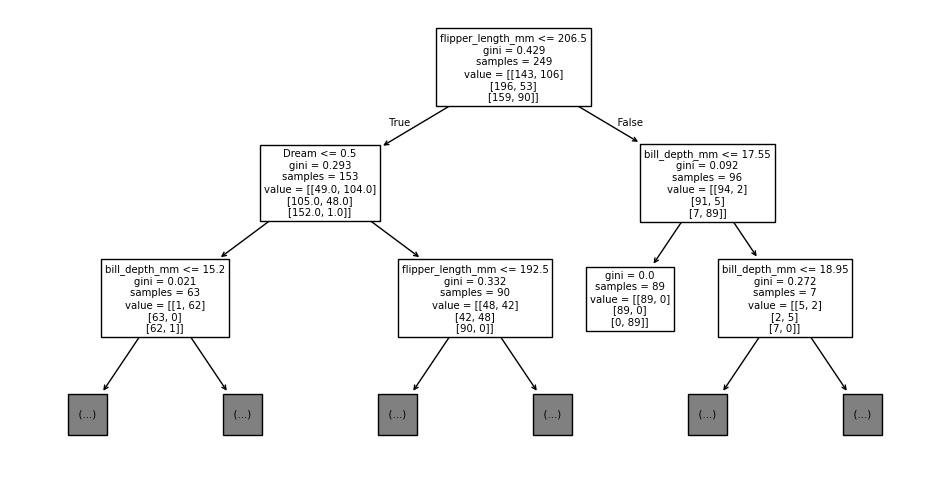

In [93]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
tree.plot_tree(
    tr, max_depth=2, feature_names=feature_names, class_names=list(class_names)
)
plt.show()  

In [94]:
text_representation = tree.export_text(
    tr, feature_names=feature_names, class_names=list(class_names)
)
print(text_representation)

|--- flipper_length_mm <= 206.50
|   |--- Dream <= 0.50
|   |   |--- bill_depth_mm <= 15.20
|   |   |   |--- class: 0
|   |   |--- bill_depth_mm >  15.20
|   |   |   |--- class: 1
|   |--- Dream >  0.50
|   |   |--- flipper_length_mm <= 192.50
|   |   |   |--- class: 2
|   |   |--- flipper_length_mm >  192.50
|   |   |   |--- class: 2
|--- flipper_length_mm >  206.50
|   |--- bill_depth_mm <= 17.55
|   |   |--- class: 0
|   |--- bill_depth_mm >  17.55
|   |   |--- bill_depth_mm <= 18.95
|   |   |   |--- class: 1
|   |   |--- bill_depth_mm >  18.95
|   |   |   |--- class: 0



### Exercise 2.2.2

Which features are important for splitting? Are there any features that seem more or less important than you expected?

Flipper length and bill length show up most often, but flipper length also shows the highest GINI when applied (~0.3 while bill length varies from ~0.1 to 0.3)